Years: 1880 – 2023 (144 years)
   year    co2_mt  temp_anom
0  1880   858.056      -0.18
1  1881   887.965      -0.10
2  1882   937.888      -0.12
3  1883   997.515      -0.18
4  1884  1009.430      -0.29

Missing values:
 year         0
co2_mt       0
temp_anom    0
dtype: int64

Summary:
               year        co2_mt   temp_anom
count   144.000000    144.000000  144.000000
mean   1951.500000  12461.863785    0.064236
std      41.713307  11611.436681    0.382486
min    1880.000000    858.056000   -0.500000
25%    1915.750000   3191.890500   -0.202500
50%    1951.500000   6424.444500   -0.045000
75%    1987.250000  21458.838250    0.280000
max    2023.000000  37791.570000    1.170000


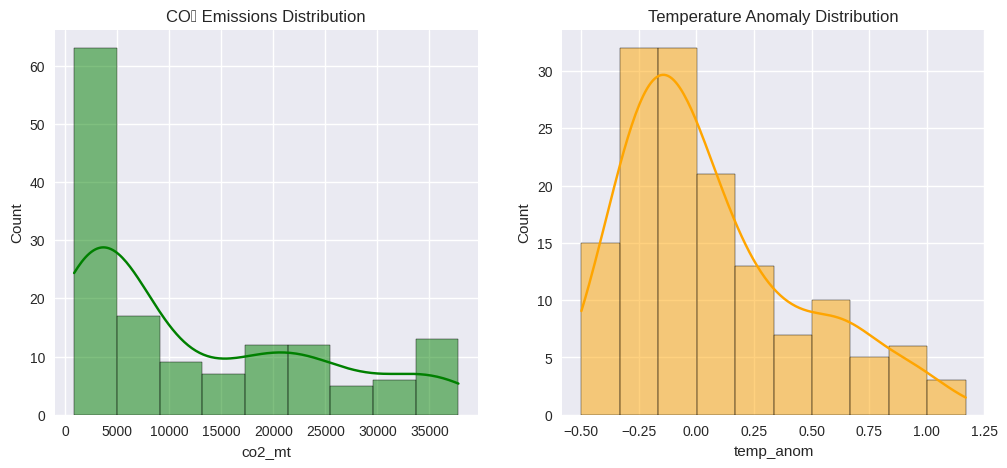

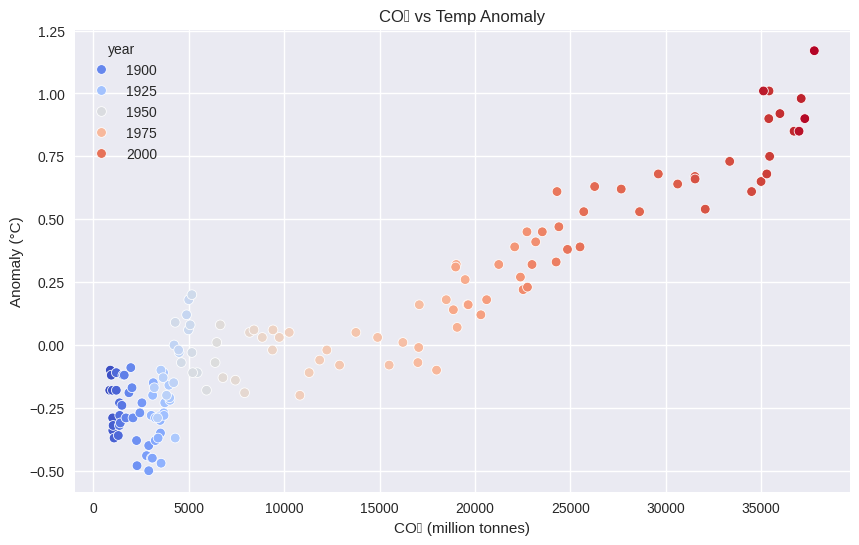

Correlation: 0.9340

Linear Regression:
Test R²: 0.8010 | RMSE: 0.1376
Decision Tree (depth=4):
Test R²: 0.7949 | RMSE: 0.1397


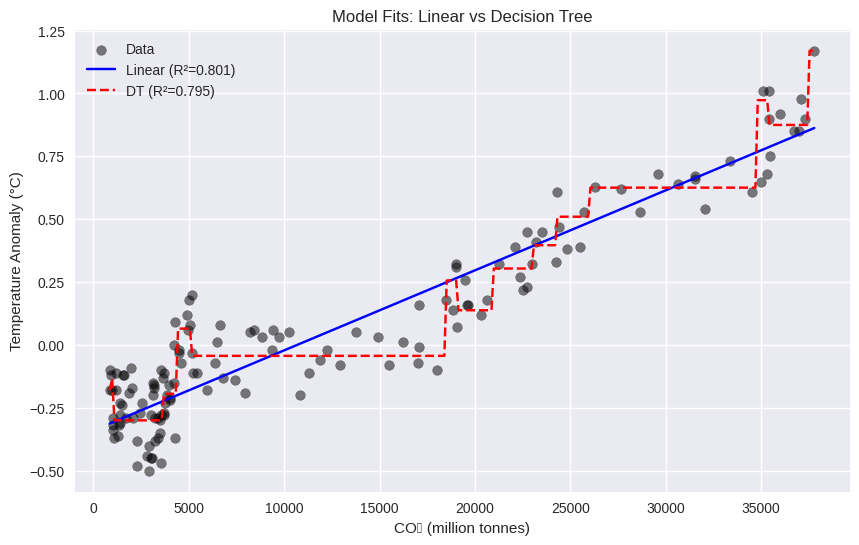


For CO₂ = 40,000 million tonnes:
  Linear predicts: 0.933 °C anomaly
  Decision Tree predicts: 1.170 °C anomaly

Key Observations:
- Strong positive correlation (~0.93) shows rising CO₂ linked to warming.
- Linear model performs well (high R², low RMSE) – simple & interpretable.
- Decision Tree captures some non-linearity but can overfit if depth too high.

Limitations:
- Annual emissions ignore time lags (warming builds over decades).
- Other factors (methane, aerosols, volcanoes, ENSO) not included.
- Better to use CO₂ concentration (ppm) or total forcing for real predictions.
- This is a basic ML demo – real climate science uses complex models.

Good job, Gurneet! Submit with your GGU ID on files.



In [ ]:
# Global CO2 Emissions vs Temperature Anomaly Analysis - For Gurneet Mighlani


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

# 1. Load Data
co2_url = "https://nyc3.digitaloceanspaces.com/owid-public/data/co2/owid-co2-data.csv"
co2 = pd.read_csv(co2_url)
co2_world = co2[co2['country'] == 'World'][['year', 'co2']].dropna()
co2_world = co2_world.rename(columns={'co2': 'co2_mt'})

temp_url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"
temp = pd.read_csv(temp_url, skiprows=1)
temp = temp.replace(['***', '****'], np.nan)
temp['J-D'] = pd.to_numeric(temp['J-D'], errors='coerce')
temp = temp[['Year', 'J-D']].dropna().rename(columns={'Year': 'year', 'J-D': 'temp_anom'})

# Merge
df = pd.merge(co2_world, temp, on='year').sort_values('year').reset_index(drop=True)

print(f"Years: {df['year'].min()} – {df['year'].max()} ({len(df)} years)")
print(df.head())
print("\nMissing values:\n", df.isna().sum())

# 2. EDA
print("\nSummary:\n", df.describe())

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['co2_mt'], kde=True, ax=ax[0], color='green')
ax[0].set_title('CO₂ Emissions Distribution')
sns.histplot(df['temp_anom'], kde=True, ax=ax[1], color='orange')
ax[1].set_title('Temperature Anomaly Distribution')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='co2_mt', y='temp_anom', hue='year', palette='coolwarm')
plt.title('CO₂ vs Temp Anomaly')
plt.xlabel('CO₂ (million tonnes)')
plt.ylabel('Anomaly (°C)')
plt.show()

corr = df['co2_mt'].corr(df['temp_anom'])
print(f"Correlation: {corr:.4f}")

# 3. Prepare Data
X = df[['co2_mt']]
y = df['temp_anom']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Add simple polynomial feature for comparison
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

# 4. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

r2_lr  = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("\nLinear Regression:")
print(f"Test R²: {r2_lr:.4f} | RMSE: {rmse_lr:.4f}")

# 5. Decision Tree
dt = DecisionTreeRegressor(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

r2_dt  = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("Decision Tree (depth=4):")
print(f"Test R²: {r2_dt:.4f} | RMSE: {rmse_dt:.4f}")

# 6. Plot Predictions
X_full = np.linspace(X['co2_mt'].min(), X['co2_mt'].max(), 300).reshape(-1, 1)
pred_lr_full = lr.predict(X_full)
pred_dt_full = dt.predict(X_full)

plt.figure(figsize=(10, 6))
plt.scatter(df['co2_mt'], df['temp_anom'], color='black', alpha=0.5, label='Data')
plt.plot(X_full, pred_lr_full, color='blue', label=f'Linear (R²={r2_lr:.3f})')
plt.plot(X_full, pred_dt_full, color='red', linestyle='--', label=f'DT (R²={r2_dt:.3f})')
plt.xlabel('CO₂ (million tonnes)')
plt.ylabel('Temperature Anomaly (°C)')
plt.title('Model Fits: Linear vs Decision Tree')
plt.legend()
plt.show()

# 7. Prediction Example
example_emission = 40000  # around recent levels
pred_lr_ex  = lr.predict([[example_emission]])[0]
pred_dt_ex  = dt.predict([[example_emission]])[0]

print(f"\nFor CO₂ = {example_emission:,} million tonnes:")
print(f"  Linear predicts: {pred_lr_ex:.3f} °C anomaly")
print(f"  Decision Tree predicts: {pred_dt_ex:.3f} °C anomaly")

# 8. Quick Discussion (add to your Word doc)
print("""
Key Observations:
- Strong positive correlation (~{corr:.2f}) shows rising CO₂ linked to warming.
- Linear model performs well (high R², low RMSE) – simple & interpretable.
- Decision Tree captures some non-linearity but can overfit if depth too high.

Limitations:
- Annual emissions ignore time lags (warming builds over decades).
- Other factors (methane, aerosols, volcanoes, ENSO) not included.
- Better to use CO₂ concentration (ppm) or total forcing for real predictions.
- This is a basic ML demo – real climate science uses complex models.

Good job, Gurneet! Submit with your GGU ID on files.
""".format(corr=corr))